# ROI volume analysis
...on images normalized to MNISymC

In [ ]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from smarts_cerebellum import week_vols_preprocessing as wv_prep
import smarts_cerebellum.globals as gl

from above cell, output: week_vols (df) - processed original df

In [ ]:
df = pd.read_csv(f'{gl.baseDir}/MNISym_WM/MNISym_coreg_WM_normalized_AtlasSUIT_summarized.tsv', sep = '\t')
week_vols = wv_prep.week_vols_preprocessing(df)

In [177]:
# put descriptive titles on plots
titles = {
    '0': 'ipsilesional',
    '1': 'contralesional',
    '3': 'control',
    '2': 'vermis'
}

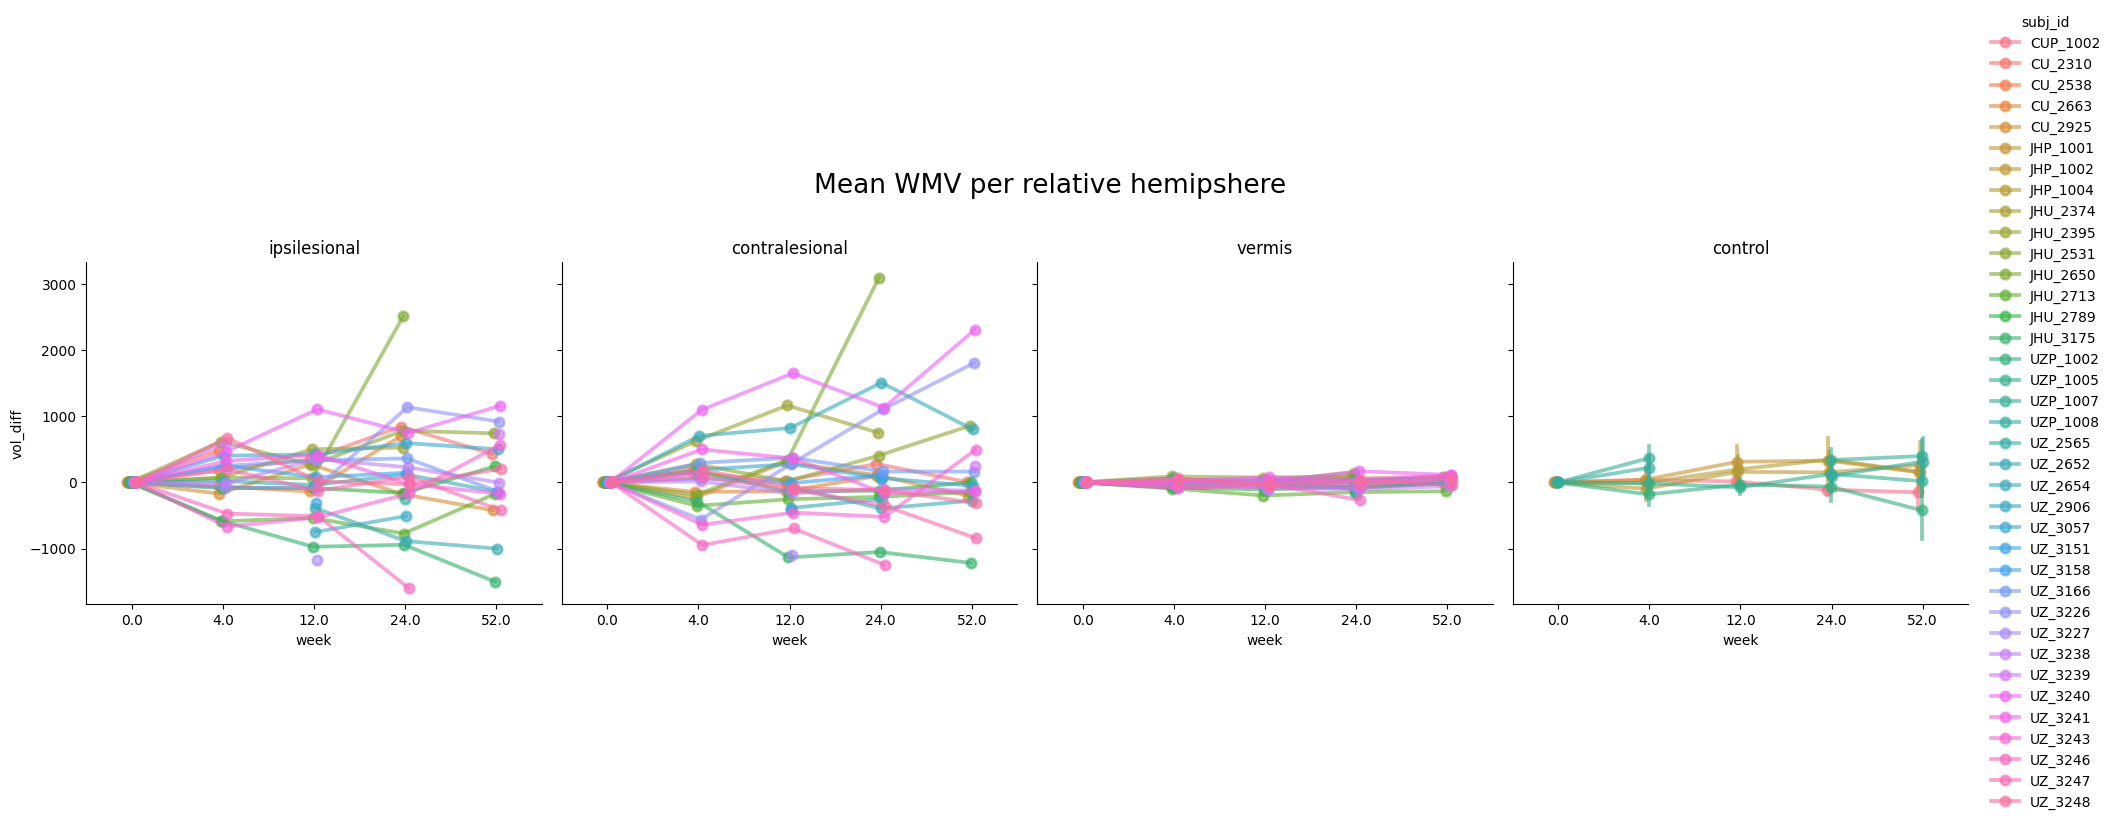

In [ ]:
excluded = ['CUP_1001', 'UZP_1004', 'UZP_1001' , 'UZP_1006' ,]#'UZP_1002', ]# ]


df_vols = week_vols[~week_vols.subj_id.isin(excluded)]

diff_plots_wmv_mean = sns.catplot(data = df_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_mean.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_mean.figure.suptitle('Mean WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_mean.figure.subplots_adjust(top = 0.8)
plt.show()
# vermis is coded as '2', gets its own plot

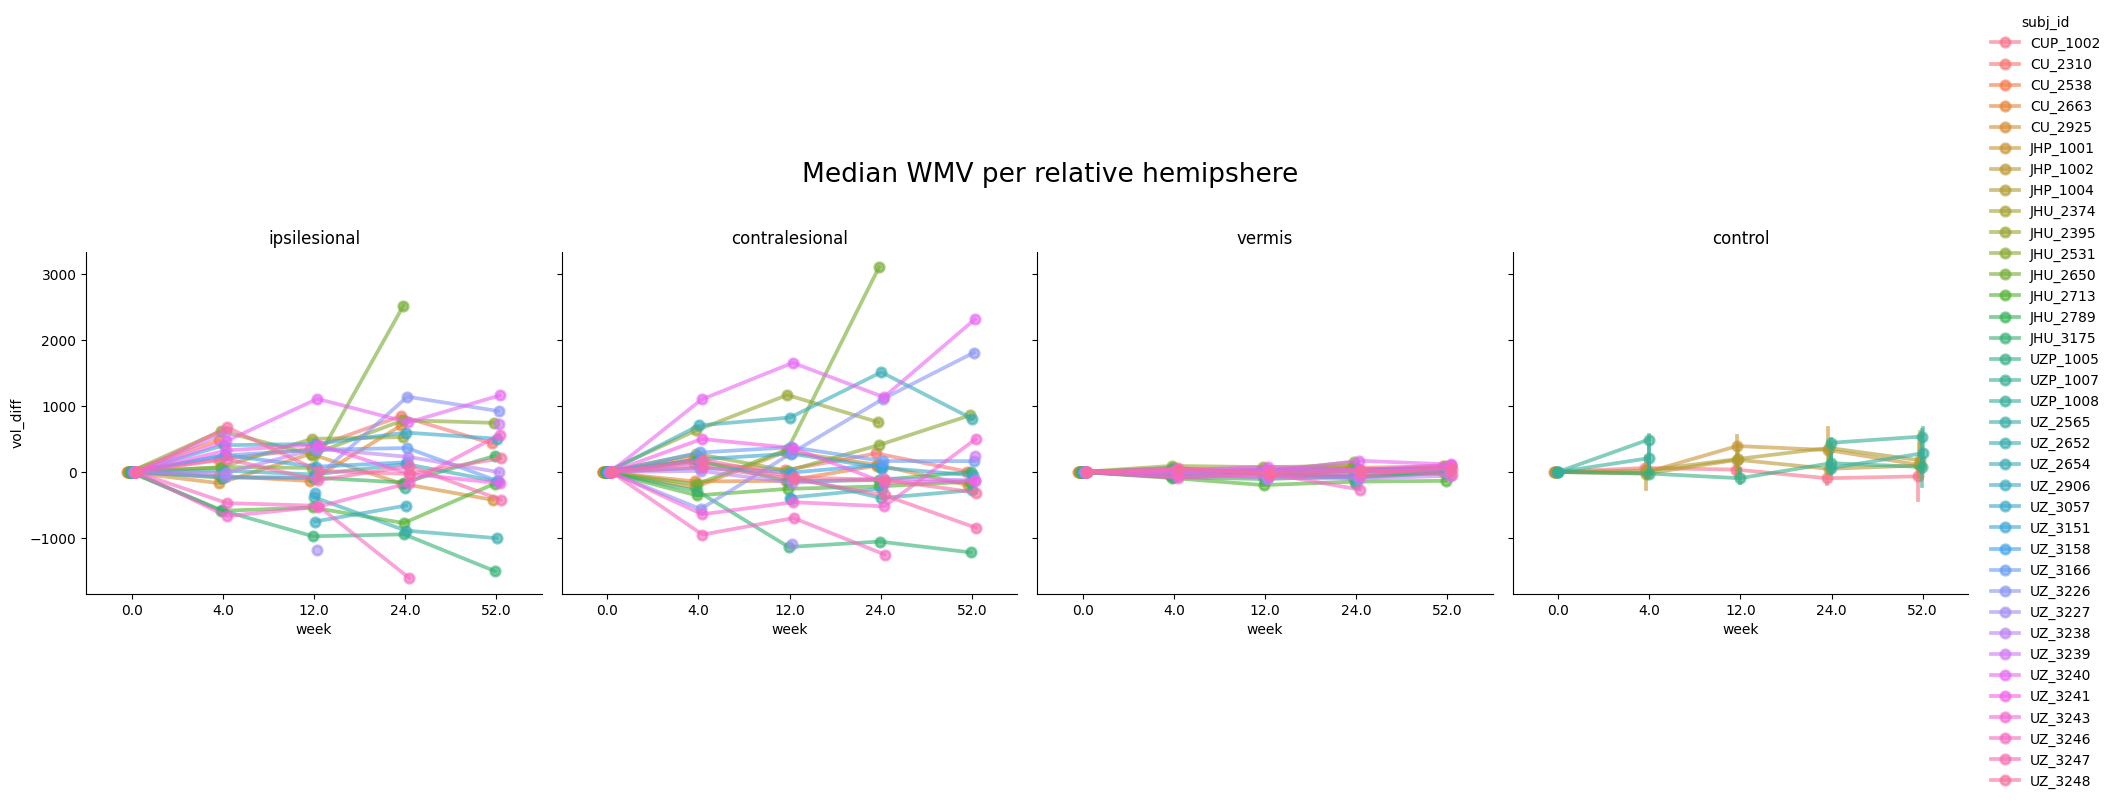

In [ ]:
# plot the medians

diff_plots_wmv_median = sns.catplot(data = df_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            estimator = 'median',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_median.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_median.figure.suptitle('Median WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_median.figure.subplots_adjust(top = 0.8)
plt.show()